# **Multi-GPU DISCO-DJ vs Quijote with distributed LPT**

This notebook mirrors `05-MultiGPU_DISCO_DJ_vs_Quijote.ipynb`, but the multi-GPU path now shards both the external-IC Fourier conversion and the nLPT initial state. The DKD evolution still uses the custom distributed PM force loop.

We compare:

1. **Single-GPU DISCO-DJ** (template path) -> density field
2. **Multi-GPU DISCO-DJ** with distributed nLPT + distributed PM -> density field
3. **Quijote N-body** snapshot -> density field

### Strategy
The single-GPU reference stays unchanged so the end-to-end comparison remains anchored to the original template. The multi-GPU path uses `discodj_dist.DiscoDJ.with_external_ics(..., sharding=sharding_field)` and `with_lpt(..., sharding=sharding_disp)`, so `Psi_ini` and `Mom_ini` are already sharded before the DKD scan starts.


## 0. Environment & imports

In [1]:
import os
# Suppress XLA's chatty rendezvous "false-positive" log lines on first
# distributed collective. This must happen BEFORE jax/jaxdecomp are imported.
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.95'

import sys, gc, time
from functools import partial
import numpy as np
import jax
import jax.numpy as jnp
from jax import config, lax
from jax.experimental.mesh_utils import create_device_mesh
from jax.experimental.multihost_utils import process_allgather
from jax.sharding import Mesh, NamedSharding, PartitionSpec as P
import matplotlib.pyplot as plt

print(f'JAX  : {jax.__version__}')
print(f'devs : {jax.devices()}')
print(f'count: {jax.device_count()}')

JAX  : 0.8.2
devs : [CudaDevice(id=0), CudaDevice(id=1)]
count: 2


In [3]:
# DISCO-DJ + the parallel discodj_dist package + jaxdecomp
_DISCODJ_SRC = '/mnt/ceph/users/spandey/quijote_v2_gotham/DISCO-DJ/src'
if _DISCODJ_SRC not in sys.path:
    sys.path.insert(0, _DISCODJ_SRC)

import jaxdecomp
from discodj_dist import DiscoDJ
from discodj_dist.nbody.steppers.dkd_pi_integrator import DKDPiIntegrator
from discodj_dist.nbody.acc_distributed import calc_acc_PM_distributed
from discodj_dist.core.distributed_pm import get_local_q_grid

all_gather = partial(process_allgather, tiled=True)
print('imports ok')


imports ok


## 1. Simulation settings (mirror the user's template)

In [4]:
sim_id  = 0                          # which Quijote LH realization
root    = '/mnt/ceph/users/spandey/discodj_runs/LH'
quijote_snap = f'/mnt/home/fvillaescusa/ceph/Quijote/Snapshots/latin_hypercube_HR/{sim_id}/snapdir_003/snap_003'

dim       = 3
precision = 'single'                 # fp32 (template choice)
boxsize   = 1000.0                   # Mpc/h
res       = 512                      # particles per dim
factor    = 2                        # PM oversampling
res_pm    = factor * res             # = 1024
n_order   = 2                        # 2LPT; distributed path also supports 3LPT
applicable_orders = (1, 2, 3)
assert n_order in applicable_orders, f'distributed nLPT currently supports {applicable_orders}'
a_ic      = 1./128.                  # initial scale factor (z=127)
n_steps   = 20
a_end     = 1./1.5                   # z=0.5
stepper   = 'fastpm'
method    = 'pm'
time_var  = 'D'
antialias = 0
grad_kernel_order    = 4
laplace_kernel_order = 0
worder    = 2
n_resample = 1
deconvolve = False
chunk_size = None

# Density-field comparison grid (template uses 256)
delta_grid = 256

# fp32 vs fp64 conversion knobs
dtype_num = 32 if precision == 'single' else 64
dtype     = jnp.float32 if dtype_num == 32 else jnp.float64
dtype_c   = jnp.complex64 if dtype_num == 32 else jnp.complex128
np_dtype  = np.float32 if dtype_num == 32 else np.float64

device = 'gpu' if any(d.platform == 'gpu' for d in jax.devices()) else 'cpu'
print(f'device={device}, res={res}, res_pm={res_pm}, n_steps={n_steps}, '
      f'precision={precision}')


device=gpu, res=512, res_pm=1024, n_steps=20, precision=single


## 2. Device mesh & sharding for the multi-GPU run

The distributed primitives expect a 2-D `Mesh` with axis names
`('x', 'y')`. With 2 GPUs the natural choice is `pdims=(1,2)`.

In [5]:
n_dev = jax.device_count()
if   n_dev >= 8: pdims = (2, 4)
elif n_dev >= 4: pdims = (2, 2)
elif n_dev >= 2: pdims = (1, 2)
else:            pdims = (1, 1)
print(f'pdims = {pdims}  (using {pdims[0]*pdims[1]} of {n_dev} devices)')

mesh_devices = create_device_mesh(pdims)
mesh         = Mesh(mesh_devices, axis_names=('x', 'y'))
sharding_disp  = NamedSharding(mesh, P('x', 'y', None, None))   # (Lx,Ly,Lz,3)
sharding_field = NamedSharding(mesh, P('x', 'y', None))         # (Lx,Ly,Lz)

pdims = (1, 2)  (using 2 of 2 devices)


## 3. Read Quijote ICs and cosmology, build single and distributed LPT states

We use the same external-IC pattern as the template: read the precomputed delta field, rescale it to z=infinity by dividing through D+(a_ic), and pass it to `with_external_ics`.

Two `DiscoDJ` objects are built:

- `dj_single`: original single-device reference path
- `dj_dist`: distributed IC FFT + distributed nLPT path


In [6]:
path_ic  = f'{root}/{sim_id}/ICs'
path_pm  = f'{root}/{sim_id}/pm'
os.makedirs(path_pm, exist_ok=True)

cosmo_all = np.loadtxt(f'{path_ic}/Cosmo_params.dat', delimiter=' ')
Om, Ob, h, ns, sigma8 = cosmo_all[:5]
Oc = Om - Ob
cosmo = dict(Omega_c=Oc, Omega_b=Ob, h=h, n_s=ns, sigma8=sigma8)
print(f'cosmology: Omega_c={Oc:.4f}, Omega_b={Ob:.4f}, h={h:.4f}, '
      f'n_s={ns:.4f}, sigma8={sigma8:.4f}')

ic_delta_host = np.load(f'{path_ic}/IC_delta{res}.npy').astype(np_dtype, copy=False)
print(f'ic_delta shape = {ic_delta_host.shape}, dtype = {ic_delta_host.dtype}')


cosmology: Omega_c=0.1087, Omega_b=0.0668, h=0.7737, n_s=0.8849, sigma8=0.6641
ic_delta shape = (512, 512, 512), dtype = float32


In [7]:
dj_single = DiscoDJ(dim=dim, res=res, device=device, precision=precision,
                    boxsize=boxsize, cosmo=cosmo, name=f'sim_{sim_id}_single')
dj_single = dj_single.with_timetables()

# Rescale the input delta from a=a_ic to a=1 (linear theory)
Dplus_aic = float(np.interp(jnp.log10(a_ic),
                            jnp.log10(dj_single.cosmo._timetables['a']),
                            dj_single.cosmo._timetables['Dplus']))
print(f'D+ (a_ic = {a_ic:.5f}) = {Dplus_aic:.4e}')

delta_ini_host = ic_delta_host / Dplus_aic

print('--- single-device LPT starting ---')
t0 = time.perf_counter()
dj_single = dj_single.with_external_ics(delta=delta_ini_host)
dj_single = dj_single.with_lpt(n_order=n_order, grad_kernel_order=grad_kernel_order,
                               try_to_jit=True)
t_single_lpt = time.perf_counter() - t0
print(f'single-device LPT: {t_single_lpt:.1f} s')

print('--- distributed IC FFT + LPT starting ---')
dj_dist = DiscoDJ(dim=dim, res=res, device=device, precision=precision,
                  boxsize=boxsize, cosmo=cosmo, name=f'sim_{sim_id}_dist')
dj_dist = dj_dist.with_timetables()
t0 = time.perf_counter()
dj_dist = dj_dist.with_external_ics(delta=delta_ini_host, sharding=sharding_field)
dj_dist = dj_dist.with_lpt(n_order=n_order, grad_kernel_order=grad_kernel_order,
                           sharding=sharding_disp, try_to_jit=True)
dj_dist._lpt.psi[f'psi_{n_order}'].block_until_ready()
t_dist_lpt = time.perf_counter() - t0
print(f'distributed IC FFT + LPT: {t_dist_lpt:.1f} s')
print(f'fphi_full sharding = {dj_dist._ics["fphi_full"].sharding}')
print(f'psi_{n_order} sharding = {dj_dist._lpt.psi[f"psi_{n_order}"].sharding}')

# Keep the old name available for cells copied from notebook 05.
dj = dj_single
print(dj_single)


D+ (a_ic = 0.00781) = 1.1418e-02
--- single-device LPT starting ---
single-device LPT: 8.7 s
--- distributed IC FFT + LPT starting ---


E0506 00:35:19.955101  335561 rendezvous.cc:92] [id=0] This thread has been waiting for `initialize clique for rank 1; clique=devices=[0,1]; is_p2p=0; root_device=-1; num_local_participants=2; incarnations=[]; run_id=-920873311` for 10 seconds and may be stuck. All 2 threads joined the rendezvous, however the leader has not marked the rendezvous as completed. Leader can be deadlocked inside the rendezvous callback.
E0506 00:35:20.198838  335561 rendezvous.cc:110] Thread is unstuck! Warning above was a false-positive. Perhaps the timeout is too short.


distributed IC FFT + LPT: 26.6 s
fphi_full sharding = NamedSharding(mesh=Mesh('x': 1, 'y': 2, axis_types=(Auto, Auto)), spec=PartitionSpec('x', 'y', None), memory_kind=device)
psi_2 sharding = NamedSharding(mesh=Mesh('x': 1, 'y': 2, axis_types=(Auto, Auto)), spec=PartitionSpec(None, 'y'), memory_kind=device)
DiscoDJ
——————————
Name: sim_0_single
Dimensions: 3D
Resolution: 512³ particles
Boxsize: 1000.0 Mpc/h
Precision: single
Device: gpu
Cosmology:
  Omega_c: 0.1087 
  Omega_b: 0.0668 
  Omega_de: 0.8245 
  h: 0.7737 
  n_s: 0.8849 
  sigma8: 0.6641 
  Omega_k: 0.0000 
  w0: -1.0000 
  wa: 0.0000


## 4. Single-GPU reference run (template path)

Identical to the user's `run_one_simulation()`.

In [8]:
print('--- single-GPU run_nbody starting ---')
t0 = time.perf_counter()
X_single, P_single, _ = dj_single.run_nbody(
    a_ini=a_ic, a_end=a_end, n_steps=n_steps, res_pm=res_pm,
    time_var=time_var, stepper=stepper, method=method,
    antialias=antialias, grad_kernel_order=grad_kernel_order,
    laplace_kernel_order=laplace_kernel_order,
    nlpt_order_ics=n_order, n_resample=n_resample,
    deconvolve=deconvolve, return_displacement=False,
    chunk_size=chunk_size)
X_single.block_until_ready()
t_single = time.perf_counter() - t0
print(f'single-GPU run_nbody: {t_single:.1f} s')

# Convert to (N, 3), match template dtype.
X_single = np.asarray(X_single, dtype=np.float32).reshape(-1, 3)
P_single = np.asarray(P_single, dtype=np.float32).reshape(-1, 3)
v_single_kms = P_single / a_end * 100.   # template's km/s convention
print(f'X_single shape={X_single.shape}, range=[{X_single.min():.2f}, {X_single.max():.2f}]')
print(f'v_single_kms range=[{v_single_kms.min():.2f}, {v_single_kms.max():.2f}]')

--- single-GPU run_nbody starting ---
single-GPU run_nbody: 19.2 s
X_single shape=(134217728, 3), range=[0.00, 1000.00]
v_single_kms range=[-3150.43, 3004.74]


## 5. Multi-GPU run via custom sharded DKD loop

The initial LPT displacement and D-derivative momentum are evaluated directly from `dj_dist`, so they are already sharded as `P('x', 'y', None, None)`. We then build the same DKD-Pi integrator coefficients that `dj_single.run_nbody` uses and run the custom distributed PM kick loop.


In [9]:
# ---- Initial state from distributed LPT ----
Psi_ini_g = dj_dist.evaluate_lpt_psi_at_a(a_ic, n_order=n_order).astype(dtype)
# IMPORTANT: with time_var='D', the integrator's internal momentum is
# d(psi)/dD (derivative w.r.t. linear growth factor), NOT d(psi)/dt_super.
Mom_ini_g = dj_dist._evaluate_lpt_property_at_a(
    a=a_ic, n_order=n_order, include_psi_0=False, D_derivative=True
).astype(dtype)
Psi_ini_g = lax.with_sharding_constraint(Psi_ini_g, sharding_disp)
Mom_ini_g = lax.with_sharding_constraint(Mom_ini_g, sharding_disp)
print(f'Psi_ini sharded shape = {Psi_ini_g.shape}, sharding = {Psi_ini_g.sharding}')

# Optional initial-condition regression against the single-device LPT state.
check_lpt_initial = True
if check_lpt_initial:
    Psi_ref_g = jax.device_put(
        dj_single.evaluate_lpt_psi_at_a(a_ic, n_order=n_order).astype(dtype),
        sharding_disp,
    )
    Mom_ref_g = jax.device_put(
        dj_single._evaluate_lpt_property_at_a(
            a=a_ic, n_order=n_order, include_psi_0=False, D_derivative=True
        ).astype(dtype),
        sharding_disp,
    )

    @jax.jit
    def lpt_metrics(x, y):
        d = x - y
        rms = jnp.sqrt(jnp.mean(d * d))
        max_abs = jnp.max(jnp.abs(d))
        norm = jnp.sqrt(jnp.mean(y * y))
        return rms, max_abs, rms / (norm + 1e-30)

    psi_rms, psi_max, psi_rel = lpt_metrics(Psi_ini_g, Psi_ref_g)
    mom_rms, mom_max, mom_rel = lpt_metrics(Mom_ini_g, Mom_ref_g)
    print(f'LPT Psi check: rms={float(psi_rms):.3e}, max={float(psi_max):.3e}, rel={float(psi_rel):.3e}')
    print(f'LPT Mom check: rms={float(mom_rms):.3e}, max={float(mom_max):.3e}, rel={float(mom_rel):.3e}')

# ---- Integrator coefficients (per-step) ----
solver = DKDPiIntegrator(
    cosmo=dj_single.cosmo,
    time_dict={'n_steps': n_steps, 'a_ini': a_ic, 'a_end': a_end,
               'time_var': time_var},
    integrator_name=stepper, use_diffrax=False, dtype_num=dtype_num)
int_args = solver.get_integrator_args()
F_end = float(dj_single.cosmo.Fplus(a_end))
print(f'integrator coeffs: alpha[0]={float(int_args["alpha"][0]):.4f}, '
      f'beta[0]={float(int_args["beta"][0]):.4e}, '
      f'ddrift1[0]={float(int_args["ddrift1"][0]):.4e}, '
      f'ddrift2[0]={float(int_args["ddrift2"][0]):.4e}')
print(f'F+(a_end) = {F_end:.4f}')


Psi_ini sharded shape = (512, 512, 512, 3), sharding = NamedSharding(mesh=Mesh('x': 1, 'y': 2, axis_types=(Auto, Auto)), spec=PartitionSpec('x', 'y', None, None), memory_kind=device)
LPT Psi check: rms=8.884e-07, max=8.024e-06, rel=1.068e-05
LPT Mom check: rms=7.781e-05, max=7.024e-04, rel=1.068e-05
integrator coeffs: alpha[0]=0.1037, beta[0]=2.8382e+01, ddrift1[0]=2.0164e-02, ddrift2[0]=2.0164e-02
F+(a_end) = 0.2674


In [10]:
# ---- halo_size for the WHOLE evolution ----
# Worst case: the largest displacement at a_end. We don't know it ahead of
# time, but for a CDM PM run with these parameters it is bounded by a small
# fraction of the box. Use a conservative halo (in PM cells) that comfortably
# covers ~30 PM cells of motion + worder//2 stencil. JIT requires halo_size
# to be static, so we pick once and reuse for all 20 steps.
cell_pm = boxsize / res_pm
# Estimate from single-GPU result if available, else fall back to a constant.
try:
    psi_end_est = X_single.reshape(res, res, res, 3) - np.asarray(dj_single.q)
    psi_end_est = ((psi_end_est + 0.5*boxsize) % boxsize) - 0.5*boxsize
    max_disp_pm_obs = float(np.abs(psi_end_est).max() / cell_pm)
except NameError:
    max_disp_pm_obs = 30.0
H_min = int(np.ceil(2 * (max_disp_pm_obs + worder//2 + 4)))
halo_size = max(8, H_min + (H_min % 2))
print(f'observed max |disp| at a_end ≈ {max_disp_pm_obs:.1f} PM cells -> halo_size = {halo_size}')

observed max |disp| at a_end ≈ 34.4 PM cells -> halo_size = 80


In [11]:
# ---- Custom DKD scan: psi, mom -> psi, mom ----
# Stack per-step coefficients into a single (n_steps, 4) array.
args_steps = jnp.stack([
    jnp.asarray(int_args['ddrift1'], dtype=dtype),
    jnp.asarray(int_args['ddrift2'], dtype=dtype),
    jnp.asarray(int_args['alpha'],   dtype=dtype),
    jnp.asarray(int_args['beta'],    dtype=dtype),
], axis=1)  # (n_steps, 4)
print(f'args_steps shape = {args_steps.shape}, dtype = {args_steps.dtype}')

@jax.jit
def run_dkd_dist(psi0, mom0, args_steps):
    def step(carry, args_step):
        psi, mom = carry
        d1, d2, alpha, beta = args_step
        # Drift 1
        psi_mid = psi + d1 * mom
        # Kick: distributed PM force
        acc = calc_acc_PM_distributed(
            psi_mid, dim=dim, res_pm=res_pm, boxsize=boxsize,
            halo_size=halo_size, sharding=sharding_disp,
            grad_order=grad_kernel_order,
            lap_order=laplace_kernel_order,
            dtype_num=dtype_num, worder=worder,
            deconvolve=deconvolve)
        mom_new = alpha * mom + beta * acc.astype(mom.dtype)
        # Drift 2
        psi_new = psi_mid + d2 * mom_new
        return (psi_new, mom_new), None
    (psi_f, mom_f), _ = lax.scan(step, (psi0, mom0), args_steps)
    return psi_f, mom_f

# ---- Run + time it ----
print('--- multi-GPU DKD scan starting ---')
t0 = time.perf_counter()
psi_final_g, mom_final_g = run_dkd_dist(Psi_ini_g, Mom_ini_g, args_steps)
psi_final_g.block_until_ready()
t_multi = time.perf_counter() - t0
print(f'multi-GPU DKD: {t_multi:.1f} s   (single-GPU was {t_single:.1f} s, '
      f'speedup = {t_single/t_multi:.2f}x)')

args_steps shape = (20, 4), dtype = float32
--- multi-GPU DKD scan starting ---


multi-GPU DKD: 9.9 s   (single-GPU was 19.2 s, speedup = 1.93x)


In [13]:
# ---- Convert to absolute Eulerian positions and km/s velocities ----
# Mirror disco-dj's run_nbody postprocess:
#   X = periodic_wrap(psi + q)
#   P_canonical = Mom * Fplus(a_end)
#   v_kms = P_canonical / a_end * 100.
q_local = get_local_q_grid(res_pm=res, boxsize=boxsize, sharding=sharding_disp,
                           dtype=dtype)

@jax.jit
def to_pos_vel(psi_g, mom_g):
    X_g  = jnp.mod(psi_g + q_local, boxsize)
    P_g  = mom_g * F_end
    v_g  = P_g / a_end * 100.0
    return X_g, v_g

X_dist_g, v_dist_g = to_pos_vel(psi_final_g, mom_final_g)
X_dist = np.asarray(all_gather(X_dist_g)).reshape(-1, 3).astype(np.float32)
v_dist = np.asarray(all_gather(v_dist_g)).reshape(-1, 3).astype(np.float32)
print(f'X_dist shape={X_dist.shape}, range=[{X_dist.min():.2f}, {X_dist.max():.2f}]')
print(f'v_dist range=[{v_dist.min():.2f}, {v_dist.max():.2f}]')

X_dist shape=(134217728, 3), range=[0.00, 1000.00]
v_dist range=[-3150.54, 3004.52]


## 6. Sanity check: multi-GPU vs single-GPU DISCO-DJ

The two paths now differ in both LPT execution placement and PM force placement, but they use the same kernels, IC field, LPT order, and integrator coefficients. The initial LPT scalar check above isolates the new distributed nLPT path; the final residual below includes both distributed LPT and distributed PM.

Positions are wrapped mod `boxsize`, so use a periodic-aware difference when computing the residual.


In [14]:
def periodic_diff(a, b, L):
    d = a - b
    return ((d + 0.5*L) % L) - 0.5*L

dx = periodic_diff(X_dist, X_single, boxsize)
dv = v_dist - v_single_kms

# Match-up: X_single is in the same C-order as our (i,j,k) particle index,
# so element-wise diff is meaningful as long as both came from the same
# Lagrangian indexing.
xmax_d = np.abs(dx).max()
xrms   = np.sqrt(np.mean(dx**2))
vmax_d = np.abs(dv).max()
vrms   = np.sqrt(np.mean(dv**2))
print(f'POSITION  : max|dx| = {xmax_d:.3e} Mpc/h    rms = {xrms:.3e} Mpc/h')
print(f'VELOCITY  : max|dv| = {vmax_d:.3e} km/s     rms = {vrms:.3e} km/s')
print(f'   (cell_pm = {cell_pm:.3f} Mpc/h, so rms/cell_pm = {xrms/cell_pm:.2e})')

POSITION  : max|dx| = 7.874e-03 Mpc/h    rms = 3.882e-04 Mpc/h
VELOCITY  : max|dv| = 2.934e+00 km/s     rms = 2.414e-02 km/s
   (cell_pm = 0.977 Mpc/h, so rms/cell_pm = 3.97e-04)


## 7. Density fields & Quijote comparison

CIC-paint each particle catalog onto a `delta_grid³` mesh (the template uses
256), turn into δ = ρ/ρ̄ − 1, and compute power spectra with Pylians.

In [15]:
import MAS_library as MASL
import readgadget
import Pk_library as PKL

def cic_delta(positions_mpch, grid, BoxSize, MAS='CIC'):
    f = np.zeros((grid, grid, grid), dtype=np.float32)
    MASL.MA(positions_mpch.astype(np.float32), f, BoxSize, MAS, verbose=False)
    f /= np.mean(f, dtype=np.float32)
    f -= 1.0
    return f

print('CIC painting single-GPU positions ...')
delta_dj_single = cic_delta(X_single, delta_grid, boxsize)

print('CIC painting multi-GPU positions ...')
delta_dj_multi  = cic_delta(X_dist,   delta_grid, boxsize)

print('Loading Quijote snapshot ...')
posq = readgadget.read_block(quijote_snap, 'POS ', [1]) / 1e3  # Mpc/h
print(f'  Quijote N_part = {len(posq)},  pos range = [{posq.min():.1f}, {posq.max():.1f}]')
delta_q = cic_delta(posq, delta_grid, boxsize)
print('done.')

CIC painting single-GPU positions ...
CIC painting multi-GPU positions ...
Loading Quijote snapshot ...
  Quijote N_part = 1073741824,  pos range = [0.0, 1000.0]
done.


In [16]:
print('Computing cross-power spectra (Pylians) ...')
Pk_single_q = PKL.XPk([delta_dj_single, delta_q], boxsize, axis=0,
                       MAS=['CIC','CIC'], threads=1)
Pk_multi_q  = PKL.XPk([delta_dj_multi,  delta_q], boxsize, axis=0,
                       MAS=['CIC','CIC'], threads=1)
Pk_single_multi = PKL.XPk([delta_dj_single, delta_dj_multi], boxsize, axis=0,
                           MAS=['CIC','CIC'], threads=1)
print('done.')

Computing cross-power spectra (Pylians) ...

Computing power spectra of the fields...
Time FFTS = 0.38
Time loop = 0.32
Time taken = 0.70 seconds

Computing power spectra of the fields...
Time FFTS = 0.38
Time loop = 0.33
Time taken = 0.71 seconds

Computing power spectra of the fields...
Time FFTS = 0.38
Time loop = 0.33
Time taken = 0.71 seconds
done.


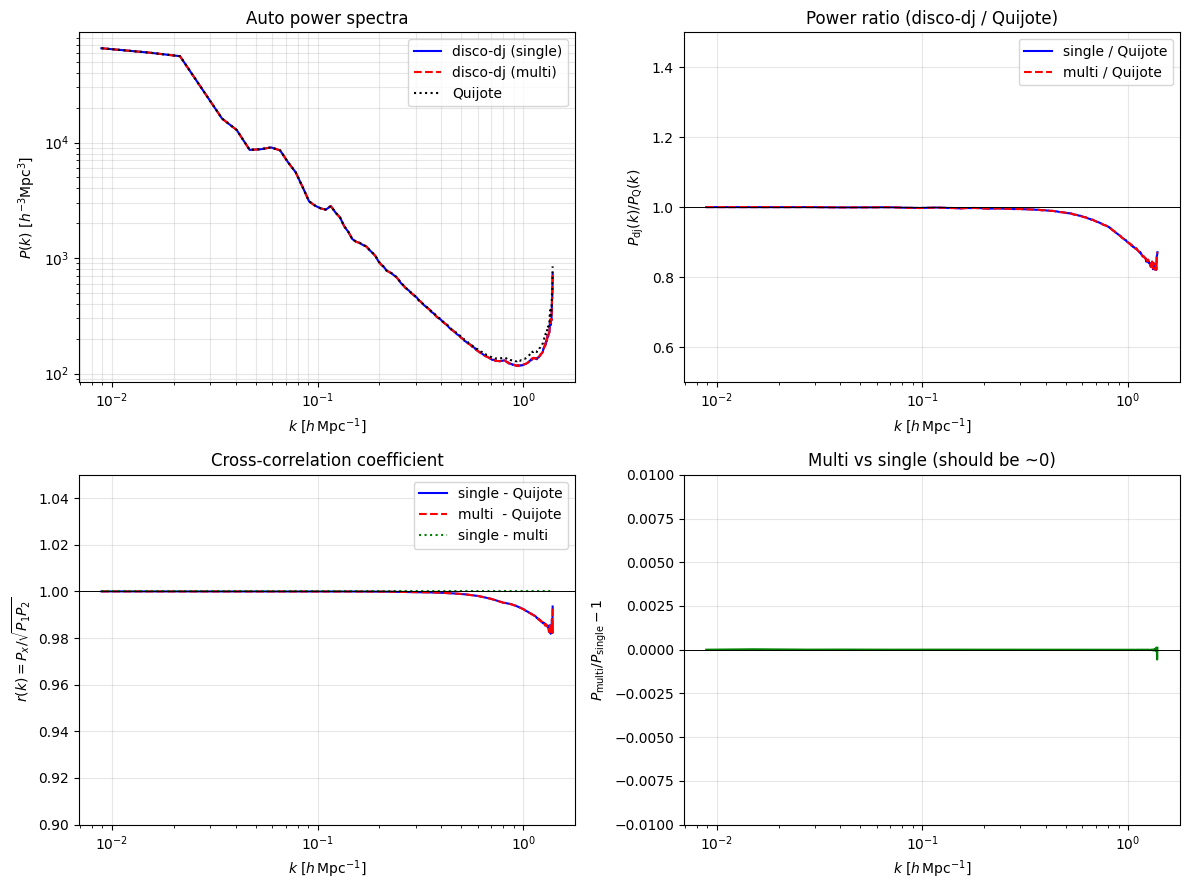

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# (a) raw P(k)
ax = axes[0, 0]
ax.loglog(Pk_single_q.k3D, Pk_single_q.Pk[:, 0, 0], 'b-',  label='disco-dj (single)')
ax.loglog(Pk_multi_q.k3D,  Pk_multi_q.Pk[:, 0, 0],  'r--', label='disco-dj (multi)')
ax.loglog(Pk_single_q.k3D, Pk_single_q.Pk[:, 0, 1], 'k:',  label='Quijote')
ax.set_xlabel(r'$k\ [h\,{\rm Mpc}^{-1}]$')
ax.set_ylabel(r'$P(k)\ [h^{-3}{\rm Mpc}^3]$')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
ax.set_title('Auto power spectra')

# (b) P_dj / P_quijote
ax = axes[0, 1]
ax.semilogx(Pk_single_q.k3D, Pk_single_q.Pk[:, 0, 0] / Pk_single_q.Pk[:, 0, 1],
            'b-',  label='single / Quijote')
ax.semilogx(Pk_multi_q.k3D,  Pk_multi_q.Pk[:, 0, 0]  / Pk_multi_q.Pk[:, 0, 1],
            'r--', label='multi / Quijote')
ax.axhline(1.0, color='k', lw=0.7)
ax.set_xlabel(r'$k\ [h\,{\rm Mpc}^{-1}]$')
ax.set_ylabel(r'$P_{\rm dj}(k) / P_{\rm Q}(k)$')
ax.set_ylim(0.5, 1.5); ax.legend(); ax.grid(True, alpha=0.3)
ax.set_title('Power ratio (disco-dj / Quijote)')

# (c) cross-correlation r(k)
ax = axes[1, 0]
r_sq = Pk_single_q.XPk[:, 0, 0] / np.sqrt(Pk_single_q.Pk[:, 0, 0] * Pk_single_q.Pk[:, 0, 1])
r_mq = Pk_multi_q.XPk[:, 0, 0]  / np.sqrt(Pk_multi_q.Pk[:, 0, 0]  * Pk_multi_q.Pk[:, 0, 1])
r_sm = Pk_single_multi.XPk[:, 0, 0] / np.sqrt(Pk_single_multi.Pk[:, 0, 0] * Pk_single_multi.Pk[:, 0, 1])
ax.semilogx(Pk_single_q.k3D, r_sq, 'b-',  label='single - Quijote')
ax.semilogx(Pk_multi_q.k3D,  r_mq, 'r--', label='multi  - Quijote')
ax.semilogx(Pk_single_multi.k3D, r_sm, 'g:', label='single - multi')
ax.axhline(1.0, color='k', lw=0.7)
ax.set_xlabel(r'$k\ [h\,{\rm Mpc}^{-1}]$')
ax.set_ylabel(r'$r(k) = P_x / \sqrt{P_1 P_2}$')
ax.set_ylim(0.9, 1.05); ax.legend(); ax.grid(True, alpha=0.3)
ax.set_title('Cross-correlation coefficient')

# (d) (multi - single) residual P(k)
ax = axes[1, 1]
ax.semilogx(Pk_single_multi.k3D,
            Pk_single_multi.Pk[:, 0, 1] / Pk_single_multi.Pk[:, 0, 0] - 1.0,
            'g-')
ax.axhline(0.0, color='k', lw=0.7)
ax.set_xlabel(r'$k\ [h\,{\rm Mpc}^{-1}]$')
ax.set_ylabel(r'$P_{\rm multi}/P_{\rm single} - 1$')
ax.set_ylim(-1e-2, 1e-2); ax.grid(True, alpha=0.3)
ax.set_title('Multi vs single (should be ~0)')

plt.tight_layout(); plt.show()

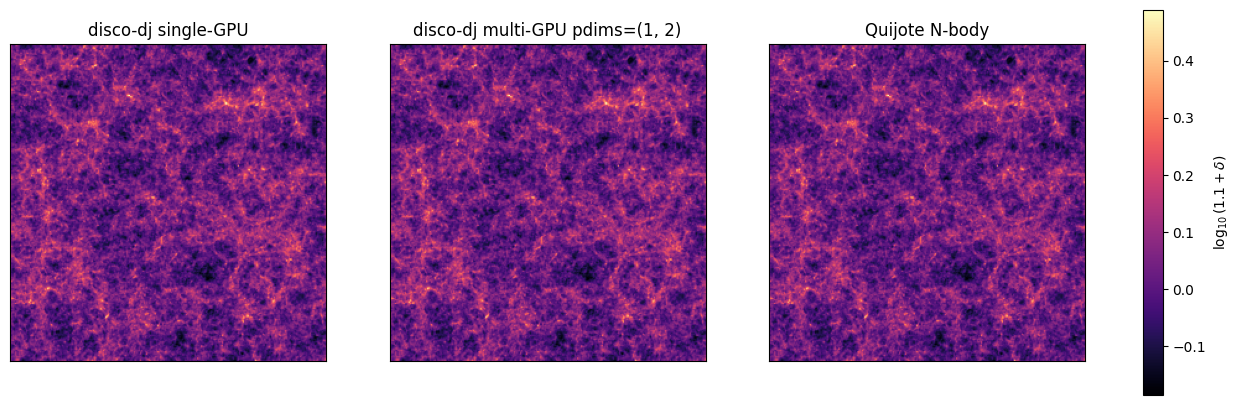

In [18]:
# Visual: density slice (avg over X axis) for the three runs.
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
proj_kw = dict(cmap='magma')
slc = slice(delta_grid // 4, 3 * delta_grid // 4)
for ax, field, title in zip(
    axs,
    [delta_dj_single, delta_dj_multi, delta_q],
    ['disco-dj single-GPU', f'disco-dj multi-GPU pdims={pdims}', 'Quijote N-body'],
):
    im = ax.imshow(np.log10(1.1 + field[slc].mean(0)), **proj_kw)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
plt.colorbar(im, ax=axs, fraction=0.025, label=r'$\log_{10}(1.1 + \delta)$')
plt.show()

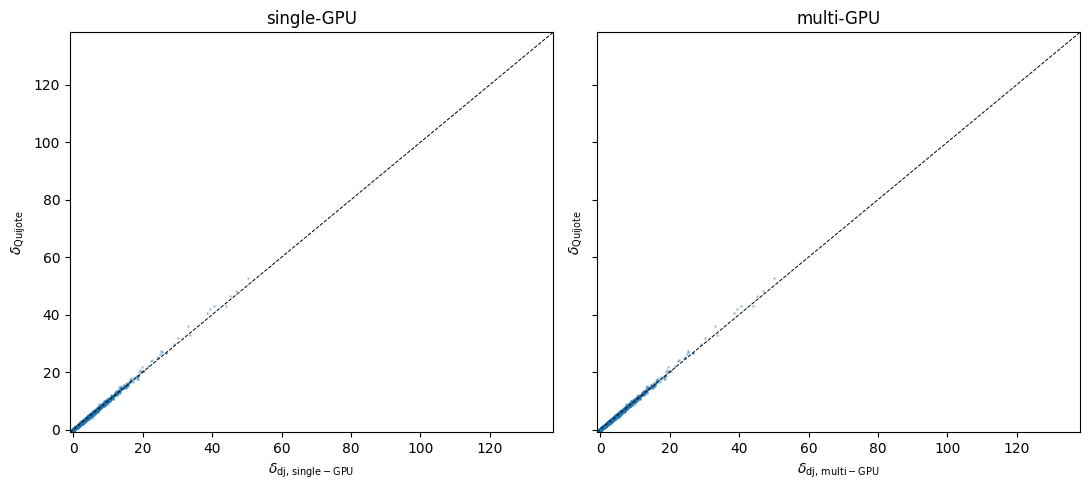

In [19]:
# Pixel-level scatter: disco-dj vs Quijote density.
fig, axs = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
sub = slice(None, None, 100)   # decimate for plotting
for ax, dj_field, label in zip(
    axs,
    [delta_dj_single, delta_dj_multi],
    ['single-GPU', 'multi-GPU'],
):
    ax.scatter(dj_field.flatten()[sub], delta_q.flatten()[sub], s=1, alpha=0.3)
    lim = (-1, max(delta_dj_single.max(), delta_q.max()))
    ax.plot(lim, lim, 'k--', lw=0.7)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(rf'$\delta_{{\rm dj,\,{label}}}$')
    ax.set_ylabel(r'$\delta_{\rm Quijote}$')
    ax.set_title(label)
plt.tight_layout(); plt.show()

## 8. Notes & next steps

* **Correctness floor:** the initial LPT checks should be at fp32/fp64 round-off for `psi_1` and `psi_2`, with slightly looser tolerance for `psi_3`. Larger final residuals can still point to a too-small `halo_size` in the distributed PM step.
* **Distributed LPT scope:** this notebook uses the new full-complex `jaxDecomp.pfft3d/pifft3d` nLPT path. It supports 1LPT, 2LPT, and 3LPT with EdS-style growth factors. `exact_growth=True` is intentionally not wired yet.
* **Scaling:** the wall-clock comparison printed above separates LPT setup from the DKD kick loop. For a fair PM scaling number, compare per-step kick times.
* **Still not sharded:** streamed IC loading and `dj.evaluate_power_spectrum` remain future work. This notebook avoids the single-GPU LPT allocation in the multi path, but the input delta file is still loaded through host memory.
* **Multi-host:** to run across SLURM nodes, put `jax.distributed.initialize()` and `jaxdecomp.init()` before any other JAX calls in an entry script.
